Contact : dhilip@iitrpr.ac.in <br>

    - Apoorv Kushwaha & Dr. T.J. Dhilip Kumar
        Quantum Dynamics Lab (410), IIT Ropar.

### 2D SF multipole expansion code for a rigid rotor-atom collision PES:
*Uses Legendre functions from scipy library of python*

In [1]:
# Import important libraries
import math
import numpy as np
import pandas as pd
from scipy.special import legendre
import matplotlib.pyplot as plt

#### read input file (PES)  give separation (remove header such as r, theta, phi, etc)
*The code assumes first column to be R (Radial Coordinate), 2nd to be theta (Angular coordinate) and 3rd column to be E(Potentials)*


In [2]:
df_inp = pd.read_csv('2D_PES.dat',header=None,sep='\s+')  # import file
lm = 4  # Difine lambda max 

In [3]:
df_inp.sort_values(by = [ 0,1], inplace=True, ascending = True)    # sort by (R, theta) in ascending order
E_inf = -78.70465827                                      # define E_infinity (Asymptotic Energy)
df_inp[2] = (df_inp[2] - E_inf)*219474.63                     # convert to cm-1
df_inp.reset_index(inplace=True, drop = True)                 # Resetting index

In [4]:
df_inp # preview

,0,1,2
0,2.5,0.0,2645.156525
1,2.5,1.0,2640.813122
2,2.5,2.0,2631.509593
3,2.5,3.0,2615.856662
4,2.5,4.0,2595.561843
...,...,...,...
9095,12.4,86.0,0.000000
9096,12.4,87.0,0.000000
9097,12.4,88.0,0.000000
9098,12.4,89.0,0.000000


In [5]:
nc=100                      # number of Radial coordinates (Must be same for all angles)
ngm = 91                    # number of angular coordinates (91 for symmetric molecule, 181 for non-symm.)
px = np.zeros((ngm,lm))     # Matrix to stores legendre coeffinients
f = np.zeros(ngm)           # Array to store part of ab initio energy 
R = np.zeros(nc)            # Array for distance R
E = np.zeros(nc)            # Array to store multipole expanded potentials
df_out = pd.DataFrame()     # dataframe that stores final V lambda (Radial coefficients)

In [6]:
V_nf= np.zeros((nc,lm))     # Numpy 2D array to store V_lambdas as they are calculated for each radial term
V_n= np.zeros(lm)           # Stores V_lambda for one radial term (Depreciated part of code no longer used!)
symmetric = True            # Verify if rigid rotor is symmetric (else put False)
if symmetric:
    sym = 2
else:
    sym = 1

In [7]:
for j2 in range (ngm):      # loop over anglular terms (considering 0-90 with 1 degree interval)
    for j3 in range (lm):      # loop over legendre terms
        pxc = legendre(j3*sym)         # Uses j3*2 for symmetric molecule (only even V_lambdas); and *1 otherwise
        ang = math.radians(j2)         # convert angles to radians
        px[j2,j3]= pxc(math.cos(ang))  # store legendre coefficient for corrosponding angle and lambda (2D)

np.save("2D_L_coeff.npy", px)    # save Legendre coefficients to numpy readable file for future use

In [8]:
px = np.load("2D_L_coeff.npy")

In [9]:
A_inv = np.linalg.pinv(px)             # take pseudo-inverse of px matrix (synonymus to least squares fit)

In [10]:
for i in range (nc):           # loop over all R   
    ct = i*ngm                 # extract start point. Since input dataframe is sorted by R and theta, 
    f = df_inp[2][ct:ct+ngm]   # potentials (V) are extracting for each R value at a time 
    V_n1 = A_inv.dot(f)        # A-inv * V gives Radial coefficients
    V_nf[i,:] = V_n1           # radial coefficients stored in 2D matrix
a12 = np.arange(lm)            # creates header for lambda terms
df_Vnf = pd.DataFrame(V_nf, columns = a12*sym) # saves final matrix into dataframe with appropriate header
df_Vnf[8:]                     # prints first 8 terms

,0,2,4,6
8,27.670772,49.251762,6.366982,-0.044231
9,8.548032,28.952351,3.792775,0.006748
10,-3.300328,15.707746,2.112041,0.205769
11,-10.223749,7.352154,1.123517,0.238140
12,-13.847281,2.430609,0.634301,-0.028438
...,...,...,...,...
95,-0.005858,-0.003273,0.000129,0.000010
96,-0.005047,-0.001974,-0.000416,0.001024
97,-0.003658,-0.003119,0.000211,-0.000308
98,-0.002881,-0.002007,-0.000323,0.001012


In [11]:
min(df_Vnf[0])   # prints minima for isotropic term

-15.826502499355303

In [13]:
x_dummy = np.arange(2.5,12.5,0.1) # Radial coordinates for plotting data
len(x_dummy)

100

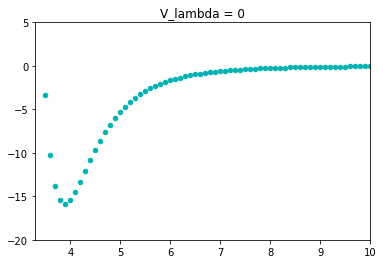

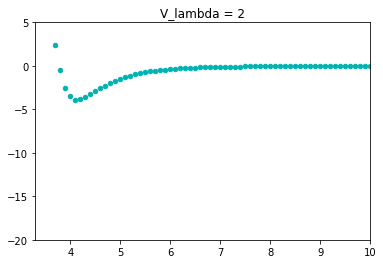

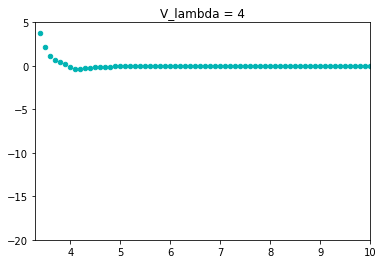

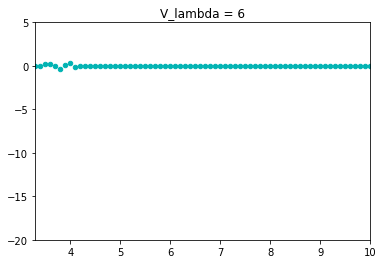

In [14]:
# Plot raw data
for i in range(0,lm):
    y_dummy = df_Vnf[i*2]
    # Plot the noisy exponential data
    plt.scatter(x_dummy, y_dummy,s=20, color='#00b3b3', label='Data')
    plt.title("V_lambda = %d" %(i*2))
    plt.ylim(-20, 5)
    plt.xlim(3.3, 10)
    plt.show()

#### save data for further use 
    1) either directly into MOLSCAT
    2) OR curve fit into appropriate functions and then use in MOLSCAT

In [15]:
df_Vnf.to_csv('2D_Vlam.dat', index=None, header=True,
                sep=',')    # save V_lam coefficients to file separated by comma